# 04 Evaluation

Ziel dieses Notebooks ist es, die Leistung des trainierten Random-Forest-Modells auf den Testdaten zu bewerten. Dafür werden zentrale Klassifikationsmetriken sowie eine Confusion Matrix verwendet.

## Imports

Für die Evaluation werden Bibliotheken zum Laden des Modells, zur Datenverarbeitung sowie zur Berechnung und Visualisierung der Bewertungsmetriken importiert.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Pfade definieren

Die Pfade zum bereinigten Datensatz, zum gespeicherten Modell und zum Ausgabeordner für Visualisierungen werden zentral definiert.

In [4]:
PROCESSED_DATA_PATH = Path("../data/processed")
MODEL_OUTPUT_PATH = Path("../outputs/models")
FIGURE_OUTPUT_PATH = Path("../outputs/figures")

FIGURE_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

data_file = PROCESSED_DATA_PATH / "cicids2017_friday_binary_clean.csv"
model_file = MODEL_OUTPUT_PATH / "random_forest_cicids2017_binary.joblib"

## Daten und Modell laden

Der bereinigte Datensatz aus der Data-Preparation-Phase sowie das gespeicherte Random-Forest-Modell werden geladen. Dadurch kann das Modell ohne erneutes Training evaluiert werden.

In [5]:
df = pd.read_csv(data_file)
rf_model = joblib.load(model_file)

print("Datensatz geladen:", df.shape)
print("Modell geladen:", type(rf_model))

Datensatz geladen: (702718, 78)
Modell geladen: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


## Features und Zielvariable trennen

Der Datensatz wird erneut in Eingabemerkmale `X` und Zielvariable `y` aufgeteilt. Die Zielvariable unterscheidet zwischen normalem Netzwerkverkehr und Angriffen:

- `0` = BENIGN / normaler Netzwerkverkehr
- `1` = Angriff

In [6]:
X = df.drop(columns=["target"])
y = df["target"]

print("Feature-Matrix:", X.shape)
print("Zielvariable:", y.shape)
print("\nKlassenverteilung:")
print(y.value_counts())

Feature-Matrix: (702718, 77)
Zielvariable: (702718,)

Klassenverteilung:
target
0    413933
1    288785
Name: count, dtype: int64


## Testdaten erzeugen

Für die Evaluation wird derselbe Train-Test-Split wie im Model-Training verwendet. Durch `random_state=42` und `stratify=y` wird sichergestellt, dass dieselbe reproduzierbare und stratifizierte Aufteilung entsteht.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Testdaten:", X_test.shape)
print("\nTest-Klassenverteilung:")
print(y_test.value_counts())

Testdaten: (140544, 77)

Test-Klassenverteilung:
target
0    82787
1    57757
Name: count, dtype: int64


## Vorhersagen erzeugen

Das trainierte Modell wird auf die Testdaten angewendet. Die vorhergesagten Klassen werden anschließend mit den tatsächlichen Klassen verglichen.

In [8]:
y_pred = rf_model.predict(X_test)

## Bewertungsmetriken

Zur Bewertung des Modells werden zentrale Klassifikationsmetriken berechnet:

- **Accuracy:** Anteil aller korrekt klassifizierten Fälle
- **Precision:** Anteil tatsächlich richtiger Angriffsmeldungen unter allen als Angriff klassifizierten Fällen
- **Recall:** Anteil erkannter Angriffe unter allen tatsächlichen Angriffen
- **F1-Score:** Kombination aus Precision und Recall

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Wert": [accuracy, precision, recall, f1]
})

metrics_df

,Metrik,Wert
0,Accuracy,0.998890
1,Precision,0.998874
2,Recall,0.998424
3,F1-Score,0.998649


## Classification Report

Der Classification Report zeigt Precision, Recall und F1-Score getrennt für normalen Netzwerkverkehr und Angriffe. Dadurch kann bewertet werden, ob das Modell beide Klassen zuverlässig erkennt.

In [10]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["BENIGN", "ATTACK"]
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     82787
      ATTACK       1.00      1.00      1.00     57757

    accuracy                           1.00    140544
   macro avg       1.00      1.00      1.00    140544
weighted avg       1.00      1.00      1.00    140544



## Confusion Matrix

Die Confusion Matrix zeigt, wie viele Testfälle korrekt oder falsch klassifiziert wurden. Dadurch wird sichtbar, ob das Modell eher normale Netzwerkverbindungen fälschlicherweise als Angriff einstuft oder echte Angriffe übersieht.

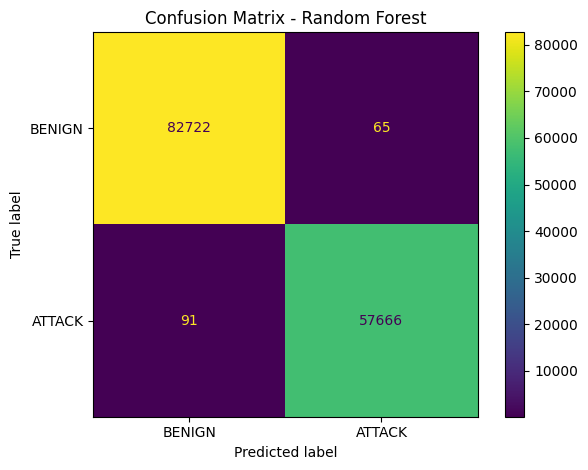

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

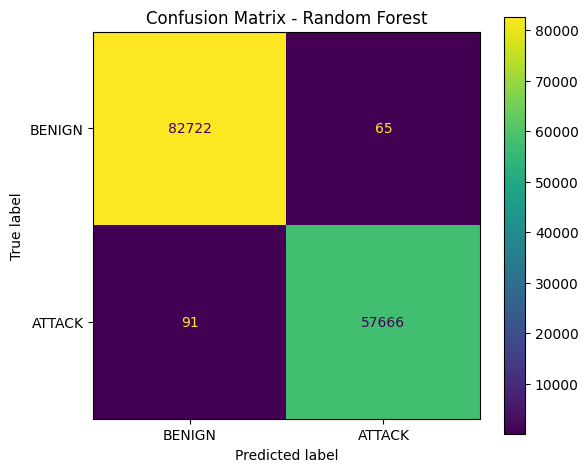

Confusion Matrix gespeichert unter: ..\outputs\figures\confusion_matrix_random_forest.png


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format="d", ax=ax)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()

output_file = FIGURE_OUTPUT_PATH / "confusion_matrix_random_forest.png"
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Confusion Matrix gespeichert unter: {output_file}")

## Speicherung der Evaluationsergebnisse

Die wichtigsten Bewertungsmetriken und die Confusion Matrix werden gespeichert, damit sie später für die Präsentation und Dokumentation verwendet werden können.

In [13]:
report_file = Path("../outputs/reports/model_evaluation_metrics.csv")
report_file.parent.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(report_file, index=False)

print(f"Metriken gespeichert unter: {report_file}")

Metriken gespeichert unter: ..\outputs\reports\model_evaluation_metrics.csv


## Zusammenfassung Evaluation

Das Random-Forest-Modell wurde auf den Testdaten evaluiert. Die Ergebnisse zeigen eine sehr hohe Klassifikationsleistung bei der Unterscheidung von normalem Netzwerkverkehr und Angriffen. Accuracy, Precision, Recall und F1-Score liegen nahezu bei 1,00.

Diese hohe Leistung deutet darauf hin, dass die Angriffsmuster im verwendeten CICIDS2017-Teildatensatz deutlich von normalem Netzwerkverkehr unterscheidbar sind. Gleichzeitig müssen die Ergebnisse kritisch betrachtet werden, da CICIDS2017 ein kontrollierter Benchmark-Datensatz ist und reale Netzwerkumgebungen deutlich komplexer sein können.

Der nächste Schritt besteht darin, mithilfe von Explainable AI zu untersuchen, welche Netzwerkmerkmale die Modellentscheidungen besonders stark beeinflussen.